# MWE: maximum a posteriori fits with `fit`

`virgil.fitting.fit` finds the maximum a posteriori parameters of a model, taking the same arguments as `virgil.likelihood.numpyro_model`: a template model, a dict of numpyro priors whose keys are the free parameters, the data, and optionally regularisers. Every parameter is optimised in unconstrained coordinates through the bijection to its prior's support, so a flux with a `LogUniform(1e-3, 0.5)` prior can never leave that range. It uses Levenberg–Marquardt (LM), L-BFGS or Adam, in float64 by default, and to sample the same posterior you pass the same arguments to `numpyro_model`.

This notebook fits a simulated binary on real JWST AMI coverage with all three optimisers. You should come away knowing how to call `fit`, what it returns, and that the optimisers agree.

In [1]:
import sys
from pathlib import Path

root = next(
    p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").exists()
)
sys.path.insert(0, str(root / "src"))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro.distributions as dist

from virgil.fitting import fit
from virgil.likelihood import whitened_residuals
from virgil.models import BinaryModelCartesian
from virgil.oidata import OIData

template = OIData(str(root / "data" / "NuHor_F480M.oifits"))
truth = BinaryModelCartesian(dra=150.0, ddec=-80.0, flux=0.02)
data = template.with_model(truth, key=jax.random.PRNGKey(0))
priors = {
    "dra": dist.Uniform(-400.0, 400.0),
    "ddec": dist.Uniform(-400.0, 400.0),
    "flux": dist.LogUniform(1e-3, 0.5),
}
start = BinaryModelCartesian(120.0, -50.0, 0.01)
print(
    f"{len(priors)} free parameters: {', '.join(priors)}; starting from {start}"
)

3 free parameters: dra, ddec, flux; starting from BinaryModelCartesian(dra=120, ddec=-50, flux=0.01)


## Fitting with each optimiser

LM works on the whitened residuals, a vector whose half sum of squares is the loss, using a matrix-free inner solve so that the Jacobian is never formed; it is the default when every term has a least-squares form, as here. L-BFGS minimises the loss directly and is needed for penalties such as maximum entropy. Adam is a plain first-order method run for a fixed number of steps. Each returns the fitted model, the parameter values and a dictionary of diagnostics.

In [2]:
results = {
    method: fit(
        start,
        priors,
        data,
        method=method,
        **({"max_steps": 3000} if method == "adam" else {}),
    )
    for method in ("lm", "lbfgs", "adam")
}
print(
    f"{'method':>7} {'dra':>9} {'ddec':>9} {'flux':>8} {'steps':>6} {'chi2/N':>7}"
)
for method, result in results.items():
    v, info = result.values, result.info
    print(
        f"{method:>7} {float(v['dra']):9.3f} {float(v['ddec']):9.3f} {float(v['flux']):8.5f} {info['steps']:6d} {info['chi2_red']:7.3f}"
    )
print(f"{'truth':>7} {150.0:9.3f} {-80.0:9.3f} {0.02:8.5f}")

 method       dra      ddec     flux  steps  chi2/N
     lm   149.486   -79.929  0.02001      8   0.801
  lbfgs   149.486   -79.929  0.02001     11   0.801
   adam   149.486   -79.929  0.02001   3000   0.801
  truth   150.000   -80.000  0.02000


## Where the fits landed

A χ² map over the companion position, at the fitted flux, shows the fits against the start and the truth. The three optimisers land on the same point, within a milliarcsecond of the truth, as expected for data at this signal-to-noise ratio. East is to the left.

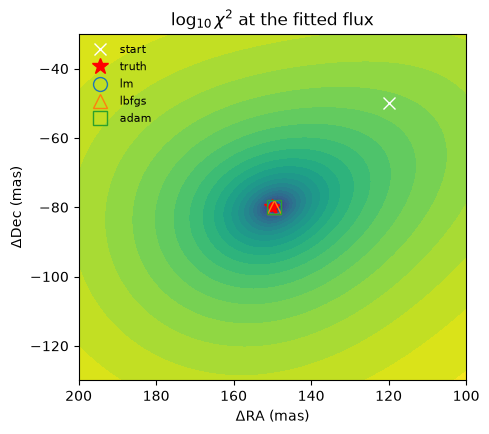

In [3]:
flux = results["lm"].values["flux"]
dra, ddec = jnp.linspace(100.0, 200.0, 81), jnp.linspace(-130.0, -30.0, 81)
chi2 = jax.vmap(
    lambda y: jax.vmap(
        lambda x: jnp.sum(
            whitened_residuals(BinaryModelCartesian(x, y, flux), data) ** 2
        )
    )(dra)
)(ddec)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.contourf(dra, ddec, jnp.log10(chi2), levels=30, cmap="viridis")
ax.plot(120.0, -50.0, "wx", ms=9, label="start")
ax.plot(150.0, -80.0, "r*", ms=12, label="truth")
for method, marker in zip(results, "o^s"):
    v = results[method].values
    ax.plot(v["dra"], v["ddec"], marker, mfc="none", ms=10, label=method)
ax.set(
    xlabel="ΔRA (mas)",
    ylabel="ΔDec (mas)",
    title=r"$\log_{10}\chi^2$ at the fitted flux",
)
ax.invert_xaxis()
ax.legend(frameon=False, fontsize=8)
plt.show()

## Precision

`fit` runs in float64 inside a local `jax.enable_x64` context by default, and casts its results back to the precision of the surrounding code, so nothing else needs to change. With `dtype="float32"` it runs in single precision instead, which is faster on GPUs; here the two agree to well within the errors.

In [4]:
x32 = fit(start, priors, data, dtype="float32").values
x64 = results["lm"].values
largest = max(abs(float(x32[p] - x64[p])) for p in priors)
print(f"largest float32 - float64 difference in the parameters: {largest:.1e}")

largest float32 - float64 difference in the parameters: 3.8e-05


## Summary

`fit` takes a template model, a prior for each free parameter and the data, the same arguments as `numpyro_model`, and returns the maximum a posteriori model with any of three optimisers, which agree here to well within the measurement errors. Priors fix both the parameters' ranges and their unconstrained coordinates, and the examples use virgil's default choices: uniform for the positions, which are locations, and log-uniform for the flux, which is a scale, and fits run in float64 without changing the rest of your code. The image fits in the following MWEs use exactly this, with pixels as the free parameters and a regulariser added.